In [68]:
import pandas as pd
from sklearn.linear_model import LinearRegression,Lasso,Ridge,LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error,r2_score,classification_report,confusion_matrix,mean_absolute_error,root_mean_squared_error
import numpy as np
from matplotlib import pyplot as plt
from sklearn.preprocessing import PolynomialFeatures,StandardScaler,MinMaxScaler
import seaborn as sns
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.naive_bayes import MultinomialNB,GaussianNB
from sklearn.tree import DecisionTreeClassifier,DecisionTreeRegressor
from imblearn.under_sampling import RandomUnderSampler
from sklearn.ensemble import RandomForestRegressor,GradientBoostingRegressor,RandomForestClassifier,GradientBoostingClassifier
from xgboost import XGBClassifier,XGBRegressor

In [69]:
df=pd.read_csv('cardekho_price.csv')

In [70]:
df.shape

(15411, 13)

In [71]:
df.head()

,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,Maruti Alto,Maruti,Alto,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5,120000
1,Hyundai Grand,Hyundai,Grand,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5,550000
2,Hyundai i20,Hyundai,i20,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5,215000
3,Maruti Alto,Maruti,Alto,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5,226000
4,Ford Ecosport,Ford,Ecosport,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5,570000


In [72]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15411 entries, 0 to 15410
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   car_name           15411 non-null  object 
 1   brand              15411 non-null  object 
 2   model              15411 non-null  object 
 3   vehicle_age        15411 non-null  int64  
 4   km_driven          15411 non-null  int64  
 5   seller_type        15411 non-null  object 
 6   fuel_type          15411 non-null  object 
 7   transmission_type  15411 non-null  object 
 8   mileage            15411 non-null  float64
 9   engine             15411 non-null  int64  
 10  max_power          15411 non-null  float64
 11  seats              15411 non-null  int64  
 12  selling_price      15411 non-null  int64  
dtypes: float64(2), int64(5), object(6)
memory usage: 1.5+ MB


In [73]:
df.isna().sum()

car_name             0
brand                0
model                0
vehicle_age          0
km_driven            0
seller_type          0
fuel_type            0
transmission_type    0
mileage              0
engine               0
max_power            0
seats                0
selling_price        0
dtype: int64

In [74]:
df.duplicated().sum()

np.int64(167)

In [75]:
df=df.drop_duplicates()

In [76]:
df.shape

(15244, 13)

In [77]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 15244 entries, 0 to 15410
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   car_name           15244 non-null  object 
 1   brand              15244 non-null  object 
 2   model              15244 non-null  object 
 3   vehicle_age        15244 non-null  int64  
 4   km_driven          15244 non-null  int64  
 5   seller_type        15244 non-null  object 
 6   fuel_type          15244 non-null  object 
 7   transmission_type  15244 non-null  object 
 8   mileage            15244 non-null  float64
 9   engine             15244 non-null  int64  
 10  max_power          15244 non-null  float64
 11  seats              15244 non-null  int64  
 12  selling_price      15244 non-null  int64  
dtypes: float64(2), int64(5), object(6)
memory usage: 1.6+ MB


In [78]:
num_cols=df[['vehicle_age','km_driven','mileage','engine','max_power','seats','selling_price']]

In [79]:
cm=num_cols.corr()
cm

,vehicle_age,km_driven,mileage,engine,max_power,seats,selling_price
vehicle_age,1.000000,0.332725,-0.257599,0.098734,0.004356,0.030268,-0.241228
km_driven,0.332725,1.000000,-0.104979,0.192721,0.044776,0.192026,-0.079548
mileage,-0.257599,-0.104979,1.000000,-0.632161,-0.532172,-0.439943,-0.305128
engine,0.098734,0.192721,-0.632161,1.000000,0.807287,0.551401,0.585713
max_power,0.004356,0.044776,-0.532172,0.807287,1.000000,0.172264,0.751058
seats,0.030268,0.192026,-0.439943,0.551401,0.172264,1.000000,0.115299
selling_price,-0.241228,-0.079548,-0.305128,0.585713,0.751058,0.115299,1.000000


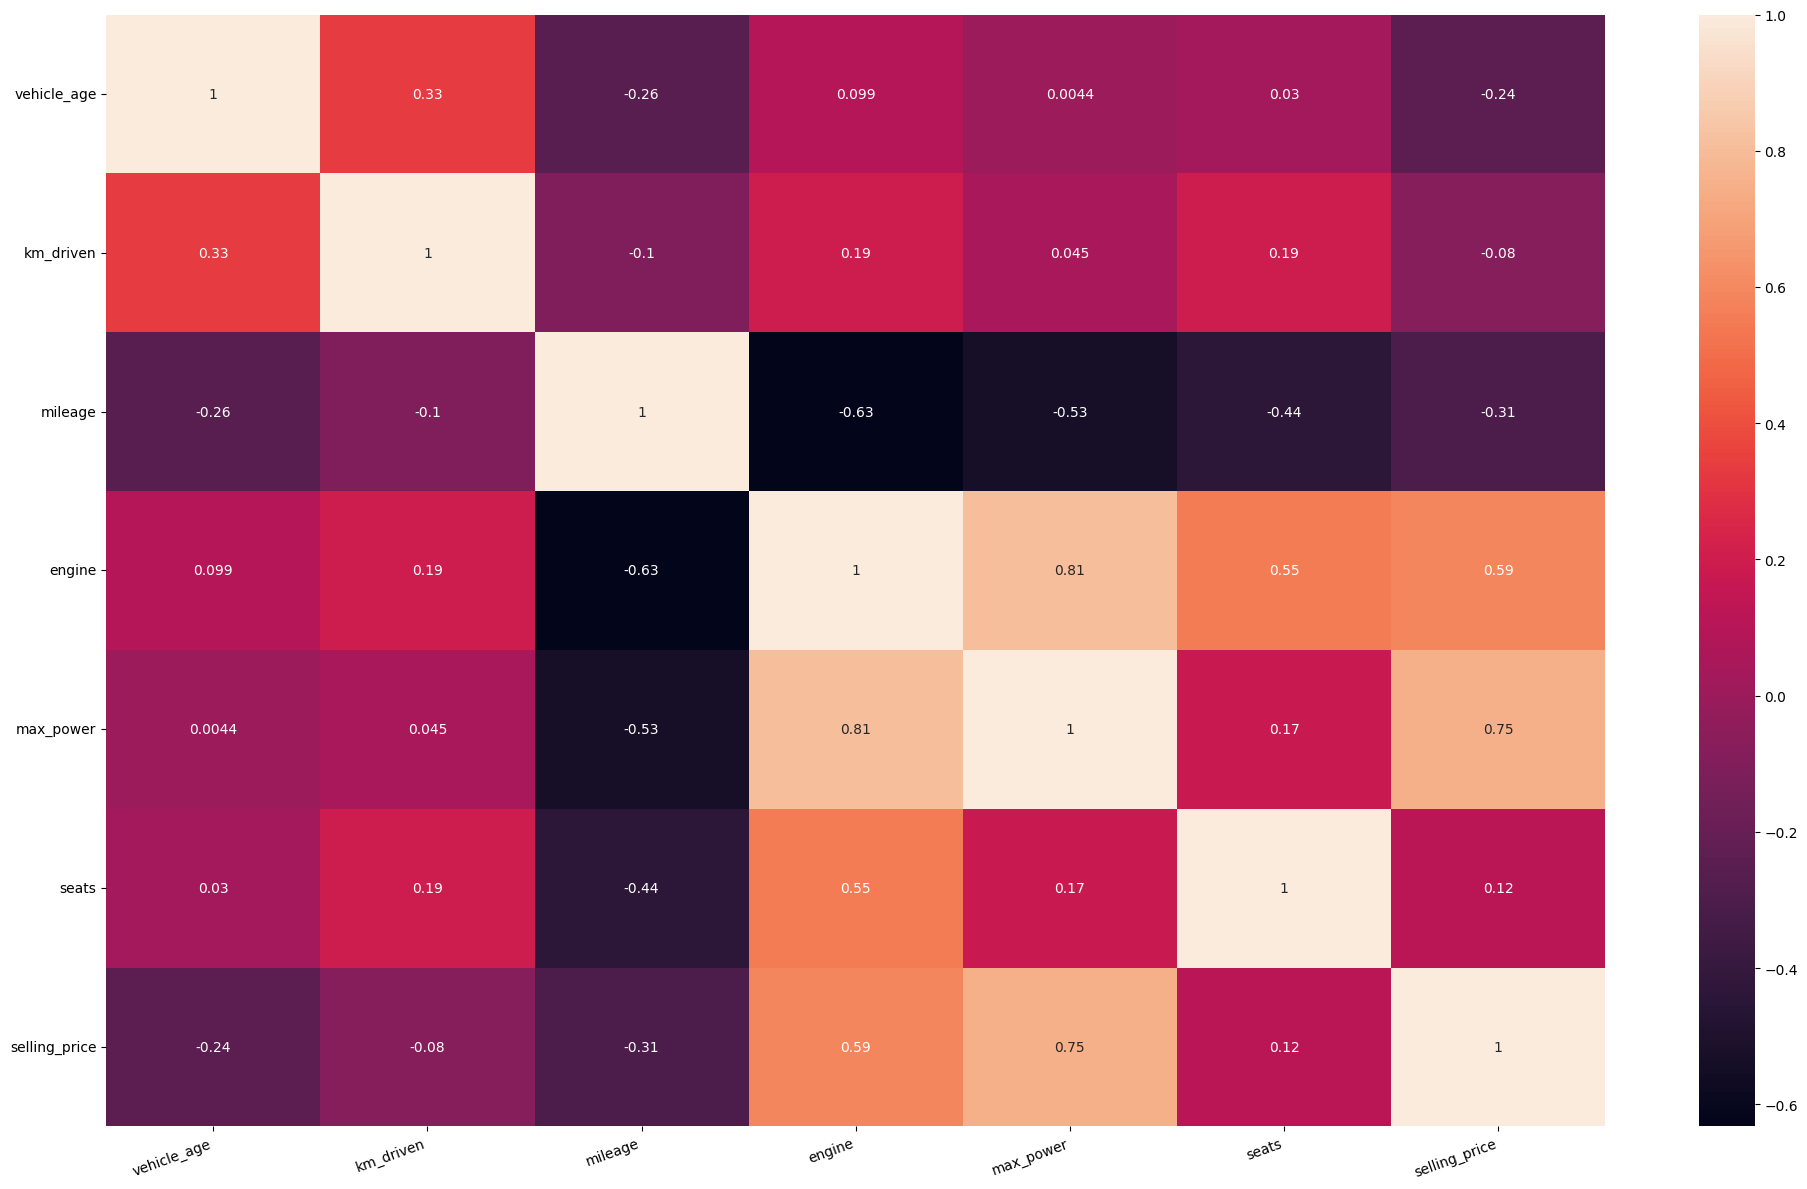

In [80]:
plt.figure(figsize=(20,12))
sns.heatmap(cm, annot=True)
plt.xticks(rotation=20, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [81]:
df[df['seller_type']=='Dealer'].shape

(9459, 13)

In [82]:
df[df['seller_type']=='Individual'].shape

(5612, 13)

In [83]:
df['brand'].value_counts()

brand
Maruti           4933
Hyundai          2952
Honda            1476
Mahindra          999
Toyota            789
Ford              776
Volkswagen        614
Renault           527
BMW               436
Tata              421
Skoda             333
Mercedes-Benz     332
Audi              190
Datsun            170
Jaguar             58
Land Rover         50
Jeep               41
Kia                32
Porsche            21
Volvo              20
MG                 19
Mini               17
Nissan             11
Lexus               9
Isuzu               7
Bentley             3
Maserati            2
ISUZU               2
Ferrari             1
Mercedes-AMG        1
Rolls-Royce         1
Force               1
Name: count, dtype: int64

<Axes: xlabel='brand'>

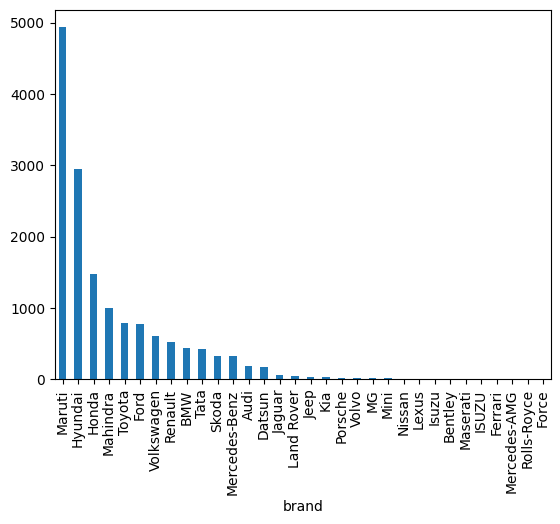

In [84]:
df['brand'].value_counts().plot(kind='bar')

In [85]:
df['seller_type'].value_counts()

seller_type
Dealer              9459
Individual          5612
Trustmark Dealer     173
Name: count, dtype: int64

<Axes: xlabel='seller_type'>

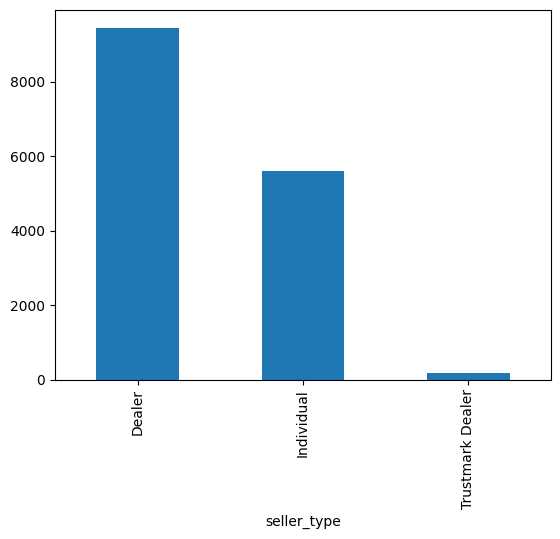

In [86]:
df['seller_type'].value_counts().plot(kind='bar')

In [87]:
df['fuel_type'].value_counts()

fuel_type
Petrol      7555
Diesel      7342
CNG          299
LPG           44
Electric       4
Name: count, dtype: int64

In [88]:
df[df['fuel_type']=='Electric']

,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
1997,Toyota Camry,Toyota,Camry,6,49500,Dealer,Electric,Automatic,19.16,2494,157.7,5,1850000
11630,Toyota Camry,Toyota,Camry,6,60000,Individual,Electric,Automatic,19.16,2494,157.7,5,2000000
14323,Toyota Camry,Toyota,Camry,5,85000,Dealer,Electric,Automatic,19.16,2494,157.7,5,1865000
14600,Toyota Camry,Toyota,Camry,6,64000,Dealer,Electric,Automatic,19.16,2494,157.7,5,1699000


In [89]:
df[df['fuel_type']=='LPG'].head()

,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
135,Maruti Wagon R,Maruti,Wagon R,9,57413,Individual,LPG,Manual,14.40,998,61.7,5,270000
842,Maruti Wagon R,Maruti,Wagon R,12,120000,Individual,LPG,Manual,17.30,1061,57.5,5,110000
1287,Maruti Wagon R,Maruti,Wagon R,9,120000,Individual,LPG,Manual,26.20,998,58.2,5,260000
1939,Hyundai Santro,Hyundai,Santro,11,35000,Dealer,LPG,Manual,13.45,1086,62.1,5,230000
3345,Maruti Wagon R,Maruti,Wagon R,14,68128,Dealer,LPG,Manual,17.30,1061,57.5,5,148000


In [90]:
df[df['fuel_type']=='CNG'].head()

,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
46,Maruti Wagon R,Maruti,Wagon R,3,53237,Trustmark Dealer,CNG,Manual,26.60,998,58.16,5,410000
169,Maruti Wagon R,Maruti,Wagon R,3,52000,Dealer,CNG,Manual,33.54,998,67.04,5,435000
182,Maruti Wagon R,Maruti,Wagon R,8,64000,Dealer,CNG,Manual,33.54,998,67.04,5,270000
314,Honda Amaze,Honda,Amaze,8,64000,Dealer,CNG,Manual,18.00,1198,86.70,5,349000
317,Maruti Celerio,Maruti,Celerio,3,28000,Dealer,CNG,Manual,31.79,998,58.33,5,455000


<Axes: xlabel='fuel_type'>

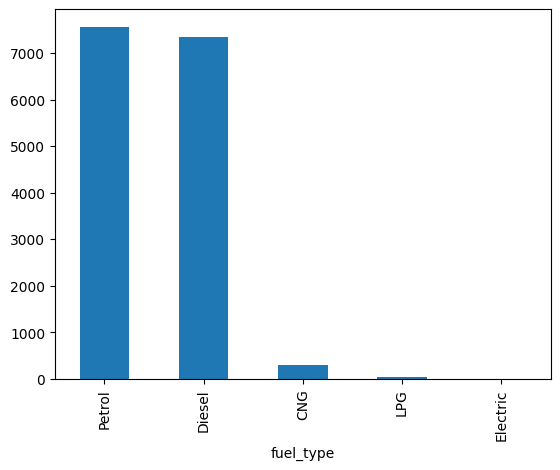

In [91]:
df['fuel_type'].value_counts().plot(kind='bar')

In [92]:
df.head()

,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,Maruti Alto,Maruti,Alto,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5,120000
1,Hyundai Grand,Hyundai,Grand,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5,550000
2,Hyundai i20,Hyundai,i20,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5,215000
3,Maruti Alto,Maruti,Alto,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5,226000
4,Ford Ecosport,Ford,Ecosport,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5,570000


In [93]:
df=df.drop(columns='car_name')

In [94]:
df.head()

,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,Maruti,Alto,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5,120000
1,Hyundai,Grand,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5,550000
2,Hyundai,i20,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5,215000
3,Maruti,Alto,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5,226000
4,Ford,Ecosport,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5,570000


In [95]:
df['transmission_type'].value_counts()

transmission_type
Manual       12094
Automatic     3150
Name: count, dtype: int64

In [96]:
df['transmission_type']=df['transmission_type'].map({'Manual':0,'Automatic':1})

In [97]:
df.head(2)

,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,Maruti,Alto,9,120000,Individual,Petrol,0,19.7,796,46.3,5,120000
1,Hyundai,Grand,5,20000,Individual,Petrol,0,18.9,1197,82.0,5,550000


In [98]:
df['seller_type'].value_counts()

seller_type
Dealer              9459
Individual          5612
Trustmark Dealer     173
Name: count, dtype: int64

In [99]:
df['seller_type']=df['seller_type'].map({'Individual':0,'Dealer':1,'Trustmark Dealer':2})

In [100]:
df.head(2)

,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,Maruti,Alto,9,120000,0,Petrol,0,19.7,796,46.3,5,120000
1,Hyundai,Grand,5,20000,0,Petrol,0,18.9,1197,82.0,5,550000


In [101]:
df[df['model']=='Grand']

,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
1,Hyundai,Grand,5,20000,0,Petrol,0,18.9,1197,82.00,5,550000
59,Hyundai,Grand,6,75000,1,Diesel,0,24.0,1120,70.00,5,350000
62,Hyundai,Grand,3,50000,0,Diesel,0,24.0,1186,73.97,5,545000
118,Hyundai,Grand,6,36000,1,Petrol,0,18.9,1197,82.00,5,400000
127,Hyundai,Grand,2,9000,0,Petrol,0,20.7,1197,81.86,5,710000
...,...,...,...,...,...,...,...,...,...,...,...,...
15350,Hyundai,Grand,2,13800,1,Petrol,0,20.7,1197,81.86,5,695000
15352,Hyundai,Grand,7,90000,1,Petrol,0,18.9,1197,82.00,5,400000
15365,Hyundai,Grand,4,60000,0,Petrol,0,18.9,1197,82.00,5,350000
15386,Hyundai,Grand,3,30000,0,Petrol,0,18.9,1197,81.86,5,456000


In [102]:
df.loc[df['model'] == 'Grand', 'model'] = 'Grand i10'

In [103]:
df[df['model']=='Grand i10']

,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
1,Hyundai,Grand i10,5,20000,0,Petrol,0,18.9,1197,82.00,5,550000
59,Hyundai,Grand i10,6,75000,1,Diesel,0,24.0,1120,70.00,5,350000
62,Hyundai,Grand i10,3,50000,0,Diesel,0,24.0,1186,73.97,5,545000
118,Hyundai,Grand i10,6,36000,1,Petrol,0,18.9,1197,82.00,5,400000
127,Hyundai,Grand i10,2,9000,0,Petrol,0,20.7,1197,81.86,5,710000
...,...,...,...,...,...,...,...,...,...,...,...,...
15350,Hyundai,Grand i10,2,13800,1,Petrol,0,20.7,1197,81.86,5,695000
15352,Hyundai,Grand i10,7,90000,1,Petrol,0,18.9,1197,82.00,5,400000
15365,Hyundai,Grand i10,4,60000,0,Petrol,0,18.9,1197,82.00,5,350000
15386,Hyundai,Grand i10,3,30000,0,Petrol,0,18.9,1197,81.86,5,456000


In [104]:
df.head(2)

,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,Maruti,Alto,9,120000,0,Petrol,0,19.7,796,46.3,5,120000
1,Hyundai,Grand i10,5,20000,0,Petrol,0,18.9,1197,82.0,5,550000


In [105]:
df['fuel_type'].value_counts()

fuel_type
Petrol      7555
Diesel      7342
CNG          299
LPG           44
Electric       4
Name: count, dtype: int64

In [106]:
df['fuel_type']=df['fuel_type'].map({'LPG':0,'CNG':1,'Petrol':2,'Diesel':3,'Electric':4})

In [107]:
df.head(2)

,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,Maruti,Alto,9,120000,0,2,0,19.7,796,46.3,5,120000
1,Hyundai,Grand i10,5,20000,0,2,0,18.9,1197,82.0,5,550000


In [108]:
new_df=pd.get_dummies(df,columns=['brand','model'],drop_first=True,dtype=int)
#new_df=pd.get_dummies(df,columns=['brand','model','seller_type','fuel_type','transmission_type'],drop_first=True,dtype=int)

In [109]:
new_df.head()

,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price,...,model_XE,model_XF,model_XL6,model_XUV300,model_XUV500,model_Yaris,model_Z4,model_i10,model_i20,model_redi-GO
0,9,120000,0,2,0,19.70,796,46.30,5,120000,...,0,0,0,0,0,0,0,0,0,0
1,5,20000,0,2,0,18.90,1197,82.00,5,550000,...,0,0,0,0,0,0,0,0,0,0
2,11,60000,0,2,0,17.00,1197,80.00,5,215000,...,0,0,0,0,0,0,0,0,1,0
3,9,37000,0,2,0,20.92,998,67.10,5,226000,...,0,0,0,0,0,0,0,0,0,0
4,6,30000,1,3,0,22.77,1498,98.59,5,570000,...,0,0,0,0,0,0,0,0,0,0


In [110]:
x=new_df.drop('selling_price',axis='columns')
y=new_df['selling_price']

In [111]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

Linear Regression

In [112]:
model_lr=LinearRegression()

In [113]:
model_lr.fit(x_train,y_train)
model_lr.score(x_test,y_test)

0.8031892058221443

In [114]:
y_pred_lr=model_lr.predict(x_test)

In [115]:
y_test[0:10]

4108      680000
10863     350000
10463     675000
3788     7500000
8851      449000
8015      620000
6779      289000
3224      900000
2425      510000
5240      550000
Name: selling_price, dtype: int64

In [116]:
y_pred_lr[0:10]

array([ 637722.33070724,  403036.3080416 ,  705476.93217834,
       3637146.97724991,  792273.06033758,  559774.96200823,
        177940.59253508, 1488439.84834889,  622865.97648832,
        747848.64301527])

In [117]:
print('r2_score:',r2_score(y_test,y_pred_lr))
print('mae:',mean_absolute_error(y_test,y_pred_lr))
print('mse:',mean_squared_error(y_test,y_pred_lr))
print('rmse:',root_mean_squared_error(y_test,y_pred_lr))

r2_score: 0.8031892058221443
mae: 169908.2875163266
mse: 119665061131.455
rmse: 345926.3810862869


Lasso

In [118]:
lasso_model = Lasso(alpha=1.0)  # Adjust alpha for Lasso
lasso_model.fit(x_train,y_train)
lasso_model.score(x_test,y_test)

c:\Users\VRISHANK\anaconda3\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.470e+14, tolerance: 1.035e+12
  model = cd_fast.enet_coordinate_descent(


0.8034803847391984

In [119]:
y_pred_ls=lasso_model.predict(x_test)

In [120]:
print('r2_score:',r2_score(y_test,y_pred_ls))
print('mae:',mean_absolute_error(y_test,y_pred_ls))
print('mse:',mean_squared_error(y_test,y_pred_ls))
print('rmse:',root_mean_squared_error(y_test,y_pred_ls))

r2_score: 0.8034803847391984
mae: 169712.54333850896
mse: 119488018286.54895
rmse: 345670.3896583405


Random Forest

In [121]:
model_rf=RandomForestRegressor()
model_rf.fit(x_train,y_train)
model_rf.score(x_test,y_test)

0.8543469590098309

In [122]:
y_pred_rf=model_rf.predict(x_test)

In [123]:
print('r2_score:',r2_score(y_test,y_pred_rf))
print('mae:',mean_absolute_error(y_test,y_pred_rf))
print('mse:',mean_squared_error(y_test,y_pred_rf))
print('rmse:',root_mean_squared_error(y_test,y_pred_rf))

r2_score: 0.8543469590098309
mae: 101114.03513949881
mse: 88560081914.61278
rmse: 297590.46005309507


In [124]:
y_test[0:10]

4108      680000
10863     350000
10463     675000
3788     7500000
8851      449000
8015      620000
6779      289000
3224      900000
2425      510000
5240      550000
Name: selling_price, dtype: int64

In [125]:
y_pred_rf[0:10]

array([ 576284.5       ,  346795.        ,  814114.16666667,
       6048740.        ,  616370.        ,  556710.        ,
        242180.        ,  947990.        ,  637519.28571429,
        562132.5       ])

In [126]:
print('r2_score:',r2_score(y_test,y_pred_rf))
print('mae:',mean_absolute_error(y_test,y_pred_rf))
print('mse:',mean_squared_error(y_test,y_pred_rf))
print('rmse:',root_mean_squared_error(y_test,y_pred_rf))

r2_score: 0.8543469590098309
mae: 101114.03513949881
mse: 88560081914.61278
rmse: 297590.46005309507


Decision Tree

In [127]:
model_dt=DecisionTreeRegressor()
model_dt.fit(x_train,y_train)
model_dt.score(x_test,y_test)

0.8241692554266683

In [128]:
y_pred_dt=model_dt.predict(x_test)

In [129]:
print('r2_score:',r2_score(y_test,y_pred_dt))
print('mae:',mean_absolute_error(y_test,y_pred_dt))
print('mse:',mean_squared_error(y_test,y_pred_dt))
print('rmse:',root_mean_squared_error(y_test,y_pred_dt))

r2_score: 0.8241692554266683
mae: 125554.38395102217
mse: 106908754095.78731
rmse: 326969.04149443156


XGBoost

In [130]:
model_xg=XGBRegressor()
model_xg.fit(x_train,y_train)
model_xg.score(x_test,y_test)

0.92970210313797

In [131]:
y_pred_xg=model_xg.predict(x_test)

In [132]:
y_test[0:10]

4108      680000
10863     350000
10463     675000
3788     7500000
8851      449000
8015      620000
6779      289000
3224      900000
2425      510000
5240      550000
Name: selling_price, dtype: int64

In [133]:
y_pred_xg[0:10]

array([ 604149.25,  372229.72,  683777.9 , 6563410.  ,  684605.56,
        538638.8 ,  229215.36,  885831.75,  581809.2 ,  605166.6 ],
      dtype=float32)

In [134]:
print('r2_score:',r2_score(y_test,y_pred_xg))
print('mae:',mean_absolute_error(y_test,y_pred_xg))
print('mse:',mean_squared_error(y_test,y_pred_xg))
print('rmse:',root_mean_squared_error(y_test,y_pred_xg))

r2_score: 0.92970210313797
mae: 95352.5703125
mse: 42742591488.0
rmse: 206742.8125
